# 🏏 IPL Run Predictor — Member 2: Modelling

## Your Job
- Build 3 ML models
- Evaluate each model
- Save charts and model files

## Instructions
- Run each cell **one by one** using **Shift + Enter**
- Do NOT skip any cell
- If you get an error, screenshot it and send to your teammate

## ⚠️ Before You Start
Make sure `cleaned_data.csv` exists in the `data` folder (Member 1 should have created it)

---
## Cell 1 — Import All Libraries
This loads all the tools we need. Run this first.

In [ ]:
# Fix file paths for Google Colab
import shutil
import os

# Create folders
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Move uploaded file to data folder
shutil.copy('cleaned_data.csv', 'data/cleaned_data.csv')

print("✅ Folders created and file moved!")

✅ Folders created and file moved!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (r2_score, mean_squared_error,
                              mean_absolute_error, accuracy_score,
                              confusion_matrix, classification_report)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## Cell 2 — Load Cleaned Data
This loads the cleaned dataset that Member 1 prepared.
You should see the shape and first few rows.

In [ ]:
df = pd.read_csv('data/cleaned_data.csv')
print('✅ Data loaded successfully!')
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

✅ Data loaded successfully!
Shape: (12040, 9)

Columns: ['match_id', 'batsman', 'runs_scored', 'balls_faced', 'strike_rate', 'venue', 'venue_avg', 'career_avg', 'last5_avg']


,match_id,batsman,runs_scored,balls_faced,strike_rate,venue,venue_avg,career_avg,last5_avg
0,548352,A Ashish Reddy,3,3.0,100.000000,"MA Chidambaram Stadium, Chepauk",20.100000,10.000000,10.0
1,598032,A Ashish Reddy,14,11.0,127.272727,Sawai Mansingh Stadium,19.842415,11.500000,16.4
2,598044,A Ashish Reddy,5,6.0,83.333333,"Rajiv Gandhi International Stadium, Uppal",19.611342,11.692308,16.0
3,598048,A Ashish Reddy,3,4.0,75.000000,M Chinnaswamy Stadium,19.957247,11.214286,16.2
4,829727,A Ashish Reddy,13,9.0,144.444444,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,17.573529,10.666667,13.0


---
## Cell 3 — Prepare Features and Target
- **Features (X)** = the 4 inputs the model learns from
- **Target (y)** = runs_scored (what we want to predict)
- **Train/Test Split** = 80% for training, 20% for testing

In [ ]:
FEATURES = ['career_avg', 'last5_avg', 'strike_rate', 'venue_avg']
TARGET   = 'runs_scored'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('✅ Features and target prepared!')
print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')
print(f'Features used    : {FEATURES}')

✅ Features and target prepared!
Training samples : 9632
Testing samples  : 2408
Features used    : ['career_avg', 'last5_avg', 'strike_rate', 'venue_avg']


---
## Cell 4 — Model 1: Simple Linear Regression
Uses only **1 feature** (career_avg) to predict runs.
This is the baseline model.

- **R²** = how well model fits (higher = better)
- **RMSE** = average prediction error in runs (lower = better)
- **MAE** = average absolute error in runs (lower = better)

In [ ]:
# Create and train the model
m1 = LinearRegression()
m1.fit(X_train[['career_avg']], y_train)

# Make predictions
p1 = m1.predict(X_test[['career_avg']])

# Evaluate
r2_1   = r2_score(y_test, p1)
rmse_1 = np.sqrt(mean_squared_error(y_test, p1))
mae_1  = mean_absolute_error(y_test, p1)

print('✅ Model 1 — Simple Linear Regression')
print(f'R²   : {r2_1:.3f}')
print(f'RMSE : {rmse_1:.2f}')
print(f'MAE  : {mae_1:.2f}')
print(f'\nFormula: Predicted Runs = {m1.coef_[0]:.3f} x career_avg + {m1.intercept_:.3f}')

✅ Model 1 — Simple Linear Regression
R²   : 0.038
RMSE : 22.23
MAE  : 17.34

Formula: Predicted Runs = 0.621 x career_avg + 8.858


---
## Cell 5 — Model 2: Multiple Linear Regression
Uses **all 4 features** to predict runs.
This should give better results than Model 1.

In [ ]:
# Create and train the model
m2 = LinearRegression()
m2.fit(X_train, y_train)

# Make predictions
p2 = m2.predict(X_test)

# Evaluate
r2_2   = r2_score(y_test, p2)
rmse_2 = np.sqrt(mean_squared_error(y_test, p2))
mae_2  = mean_absolute_error(y_test, p2)

print('✅ Model 2 — Multiple Linear Regression')
print(f'R²   : {r2_2:.3f}')
print(f'RMSE : {rmse_2:.2f}')
print(f'MAE  : {mae_2:.2f}')

# Feature importance
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': m2.coef_
}).sort_values('Coefficient', ascending=False)

print('\nFeature Coefficients (higher = more important):')
print(coef_df.to_string(index=False))

✅ Model 2 — Multiple Linear Regression
R²   : 0.298
RMSE : 18.99
MAE  : 13.68

Feature Coefficients (higher = more important):
    Feature  Coefficient
 career_avg     0.568963
  venue_avg     0.295971
strike_rate     0.179495
  last5_avg     0.063087


---
## Cell 6 — Model 3: Logistic Regression
Classifies each innings as **Flop / Average / Excellent**

- Flop = 0 to 15 runs
- Average = 16 to 40 runs  
- Excellent = 41+ runs

⚠️ Note: We use StandardScaler here — Logistic Regression needs all features on the same scale

In [ ]:
# Convert runs to categories
def label(r):
    if r <= 15:   return 'Flop'
    elif r <= 40: return 'Average'
    else:         return 'Excellent'

y_train_cat = y_train.apply(label)
y_test_cat  = y_test.apply(label)

print('Category distribution in test set:')
print(y_test_cat.value_counts())

# Scale features
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

# Train model
m3 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
m3.fit(X_tr_sc, y_train_cat)
p3  = m3.predict(X_te_sc)
acc = accuracy_score(y_test_cat, p3)

print('\n✅ Model 3 — Logistic Regression')
print(f'Accuracy: {acc:.3f}')
print('\nClassification Report:')
print(classification_report(y_test_cat, p3))

Category distribution in test set:
runs_scored
Flop         1113
Average       797
Excellent     498
Name: count, dtype: int64

✅ Model 3 — Logistic Regression
Accuracy: 0.590

Classification Report:
              precision    recall  f1-score   support

     Average       0.47      0.36      0.41       797
   Excellent       0.42      0.61      0.50       498
        Flop       0.77      0.75      0.76      1113

    accuracy                           0.59      2408
   macro avg       0.55      0.57      0.55      2408
weighted avg       0.60      0.59      0.59      2408



---
## Cell 7 — All Evaluation Charts
This creates 6 charts in one figure:
1. Simple LR — Actual vs Predicted
2. Multiple LR — Actual vs Predicted
3. Feature Coefficients
4. Confusion Matrix
5. R² Comparison
6. RMSE Comparison

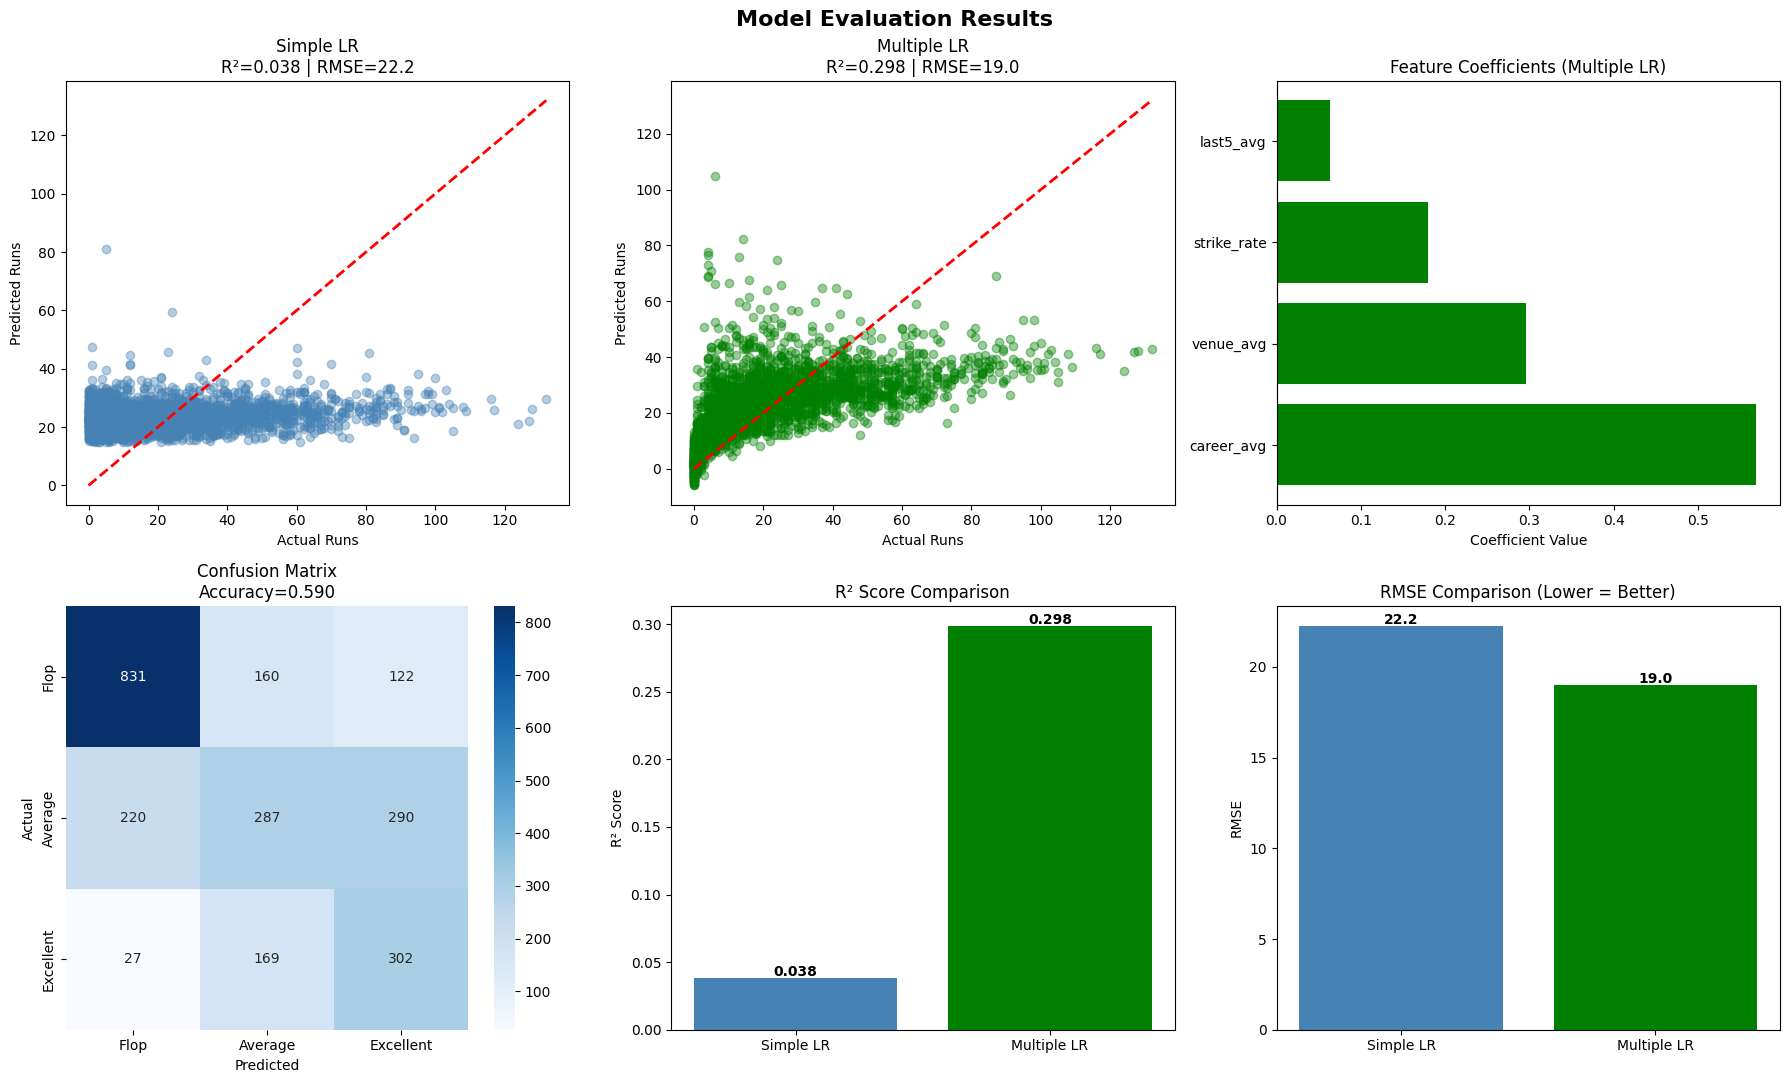

✅ All charts saved to data/model_results.png!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Model Evaluation Results', fontsize=16, fontweight='bold')

# 1. Simple LR — Actual vs Predicted
axes[0,0].scatter(y_test, p1, alpha=0.4, color='steelblue')
axes[0,0].plot([y_test.min(), y_test.max()],
               [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,0].set_title(f'Simple LR\nR²={r2_1:.3f} | RMSE={rmse_1:.1f}')
axes[0,0].set_xlabel('Actual Runs')
axes[0,0].set_ylabel('Predicted Runs')

# 2. Multiple LR — Actual vs Predicted
axes[0,1].scatter(y_test, p2, alpha=0.4, color='green')
axes[0,1].plot([y_test.min(), y_test.max()],
               [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,1].set_title(f'Multiple LR\nR²={r2_2:.3f} | RMSE={rmse_2:.1f}')
axes[0,1].set_xlabel('Actual Runs')
axes[0,1].set_ylabel('Predicted Runs')

# 3. Feature Coefficients
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
axes[0,2].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
axes[0,2].set_title('Feature Coefficients (Multiple LR)')
axes[0,2].axvline(0, color='black', lw=0.8)
axes[0,2].set_xlabel('Coefficient Value')

# 4. Confusion Matrix
cm = confusion_matrix(y_test_cat, p3, labels=['Flop','Average','Excellent'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Flop','Average','Excellent'],
            yticklabels=['Flop','Average','Excellent'], ax=axes[1,0])
axes[1,0].set_title(f'Confusion Matrix\nAccuracy={acc:.3f}')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')

# 5. R² Comparison
models = ['Simple LR', 'Multiple LR']
r2s    = [r2_1, r2_2]
axes[1,1].bar(models, r2s, color=['steelblue','green'])
axes[1,1].set_title('R² Score Comparison')
axes[1,1].set_ylabel('R² Score')
for i, v in enumerate(r2s):
    axes[1,1].text(i, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold')

# 6. RMSE Comparison
rmses = [rmse_1, rmse_2]
axes[1,2].bar(models, rmses, color=['steelblue','green'])
axes[1,2].set_title('RMSE Comparison (Lower = Better)')
axes[1,2].set_ylabel('RMSE')
for i, v in enumerate(rmses):
    axes[1,2].text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('data/model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ All charts saved to data/model_results.png!')

---
## Cell 8 — Save All Models
This saves the trained models as .pkl files so Member 3 can use them in the Streamlit app.

In [ ]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(m2,     'multiple_lr.pkl')
joblib.dump(m3,     'logistic_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print('✅ All models saved to /models/ folder!')
print('  - multiple_lr.pkl')
print('  - logistic_model.pkl')
print('  - scaler.pkl')
print('\n👉 Tell Member 3 — models are ready!')

✅ All models saved to /models/ folder!
  - multiple_lr.pkl
  - logistic_model.pkl
  - scaler.pkl

👉 Tell Member 3 — models are ready!


---
## Cell 9 — Final Summary Table
This prints a clean comparison of all 3 models.

In [ ]:
print('=' * 55)
print('         FINAL MODEL COMPARISON')
print('=' * 55)

summary = pd.DataFrame({
    'Model'    : ['Simple LR', 'Multiple LR', 'Logistic LR'],
    'Type'     : ['Regression', 'Regression', 'Classification'],
    'R² / Acc' : [f'{r2_1:.3f}', f'{r2_2:.3f}', f'{acc:.3f}'],
    'RMSE'     : [f'{rmse_1:.2f}', f'{rmse_2:.2f}', 'N/A'],
    'MAE'      : [f'{mae_1:.2f}', f'{mae_2:.2f}', 'N/A'],
})
print(summary.to_string(index=False))
print('\n✅ Member 2 tasks complete! Now commit your work.')

         FINAL MODEL COMPARISON
      Model           Type R² / Acc  RMSE   MAE
  Simple LR     Regression    0.038 22.23 17.34
Multiple LR     Regression    0.298 18.99 13.68
Logistic LR Classification    0.590   N/A   N/A

✅ Member 2 tasks complete! Now commit your work.


---
## ✅ Final Step — Commit Your Work

Open PowerShell and run these commands:

```bash
cd Desktop/IPL-Run-Predictor
git add .
git commit -m "Stage 6,7,8: all 3 models built, evaluated and saved"
git push origin feature/modelling
```

Then tell Member 3 the models are ready in the `/models/` folder! 🚀